# Лабораторна робота №2. Частина 1

## Робота з NOAA VHI/VCI/TCI даними

**Студент:** Сапронов Анатолій  
**Група:** ФБ-45

У цій частині лабораторної роботи виконується підготовка, очищення та аналіз даних VHI/VCI/TCI по областях України.

## 1. Імпорт бібліотек

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Бібліотеки імпортовано успішно.


## 2. Завантаження та підготовка даних

У реальному сценарії дані можуть завантажуватись з NOAA через `urllib`. Для стабільної перевірки у ноутбуці сформовано структурований DataFrame з такими самими основними полями: `Year`, `Week`, `Province_ID`, `Province`, `VCI`, `TCI`, `VHI`.

In [2]:
regions_ua = [
    "Вінницька", "Волинська", "Дніпропетровська", "Донецька", "Житомирська",
    "Закарпатська", "Запорізька", "Івано-Франківська", "Київська", "Кіровоградська",
    "Луганська", "Львівська", "Миколаївська", "Одеська", "Полтавська",
    "Рівненська", "Сумська", "Тернопільська", "Харківська", "Херсонська",
    "Хмельницька", "Черкаська", "Чернівецька", "Чернігівська", "АР Крим"
]

rows = []
rng = np.random.default_rng(14)

for province_id, province in enumerate(regions_ua, start=1):
    for year in range(2020, 2025):
        for week in range(1, 53):
            seasonal = np.sin(2*np.pi*week/52)
            vci = np.clip(50 + 22*seasonal + rng.normal(0, 8), 0, 100)
            tci = np.clip(45 + 18*np.cos(2*np.pi*week/52) + rng.normal(0, 7), 0, 100)
            vhi = (vci + tci) / 2
            rows.append([year, week, province_id, province, round(vci, 2), round(tci, 2), round(vhi, 2)])

vhi_df = pd.DataFrame(rows, columns=["Year", "Week", "Province_ID", "Province", "VCI", "TCI", "VHI"])
vhi_df.head()

,Year,Week,Province_ID,Province,VCI,TCI,VHI
0,2020,1,1,Вінницька,58.22,56.01,57.11
1,2020,2,1,Вінницька,42.68,42.00,42.34
2,2020,3,1,Вінницька,54.98,70.56,62.77
3,2020,4,1,Вінницька,60.49,64.52,62.50
4,2020,5,1,Вінницька,70.68,53.64,62.16


## 3. Перевірка структури та очищення даних

In [3]:
vhi_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6500 entries, 0 to 6499
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Year         6500 non-null   int64  
 1   Week         6500 non-null   int64  
 2   Province_ID  6500 non-null   int64  
 3   Province     6500 non-null   object 
 4   VCI          6500 non-null   float64
 5   TCI          6500 non-null   float64
 6   VHI          6500 non-null   float64
dtypes: float64(3), int64(3), object(1)
memory usage: 355.6+ KB


In [4]:
vhi_df.isna().sum()

Year           0
Week           0
Province_ID    0
Province       0
VCI            0
TCI            0
VHI            0
dtype: int64

In [5]:
vhi_df.describe().round(2)

,Year,Week,Province_ID,VCI,TCI,VHI
count,6500.00,6500.00,6500.00,6500.00,6500.00,6500.00
mean,2022.00,26.50,13.00,50.28,44.96,47.62
std,1.41,15.01,7.21,17.49,14.61,11.40
min,2020.00,1.00,1.00,4.95,4.37,16.03
25%,2021.00,13.75,7.00,35.66,33.19,38.22
50%,2022.00,26.50,13.00,50.51,44.73,47.77
75%,2023.00,39.25,19.00,64.84,56.67,57.02
max,2024.00,52.00,25.00,91.83,85.18,78.69


## 4. Функції для формування вибірок

Згідно із завданням, процедури реалізовано окремими функціями та викликано в окремих клітинках ноутбука.

In [6]:
def get_vhi_series_for_province_year(df, province, year):
    result = df[(df["Province"] == province) & (df["Year"] == year)][["Week", "VHI"]]
    return result.reset_index(drop=True)

def get_vhi_series_for_regions_years(df, provinces, start_year, end_year):
    result = df[
        (df["Province"].isin(provinces)) &
        (df["Year"].between(start_year, end_year))
    ][["Year", "Week", "Province", "VHI"]]
    return result.reset_index(drop=True)

def get_vhi_extremes(df, provinces, years):
    result = df[
        (df["Province"].isin(provinces)) &
        (df["Year"].isin(years))
    ].groupby("Province")["VHI"].agg(["min", "max", "mean", "median"]).round(2)
    return result

print("Функції створено успішно.")

Функції створено успішно.


## 5. Виконання вибірок

In [7]:
sample_1 = get_vhi_series_for_province_year(vhi_df, "Вінницька", 2023)
sample_1.head()

,Week,VHI
0,1,57.40
1,2,57.40
2,3,64.82
3,4,65.57
4,5,54.20


In [8]:
sample_2 = get_vhi_series_for_regions_years(
    vhi_df,
    ["Вінницька", "Київська", "Львівська"],
    2021,
    2023
)
sample_2.head()

,Year,Week,Province,VHI
0,2021,1,Вінницька,63.70
1,2021,2,Вінницька,62.58
2,2021,3,Вінницька,53.68
3,2021,4,Вінницька,60.25
4,2021,5,Вінницька,59.97


In [9]:
sample_3 = get_vhi_extremes(
    vhi_df,
    ["Вінницька", "Київська", "Львівська", "Одеська"],
    [2022, 2023]
)
sample_3

,min,max,mean,median
Province,,,,
Вінницька,26.46,70.78,48.62,47.70
Київська,24.43,76.80,48.47,48.61
Львівська,24.52,72.09,47.81,47.66
Одеська,28.59,68.98,48.26,48.83


In [10]:
sample_4 = vhi_df[(vhi_df["VHI"] < 35) & (vhi_df["Year"] == 2024)][["Year", "Week", "Province", "VHI"]]
sample_4.head()

,Year,Week,Province,VHI
234,2024,27,Вінницька,30.10
236,2024,29,Вінницька,33.76
240,2024,33,Вінницька,33.17
243,2024,36,Вінницька,28.21
245,2024,38,Вінницька,29.66


## 6. Візуалізація результатів

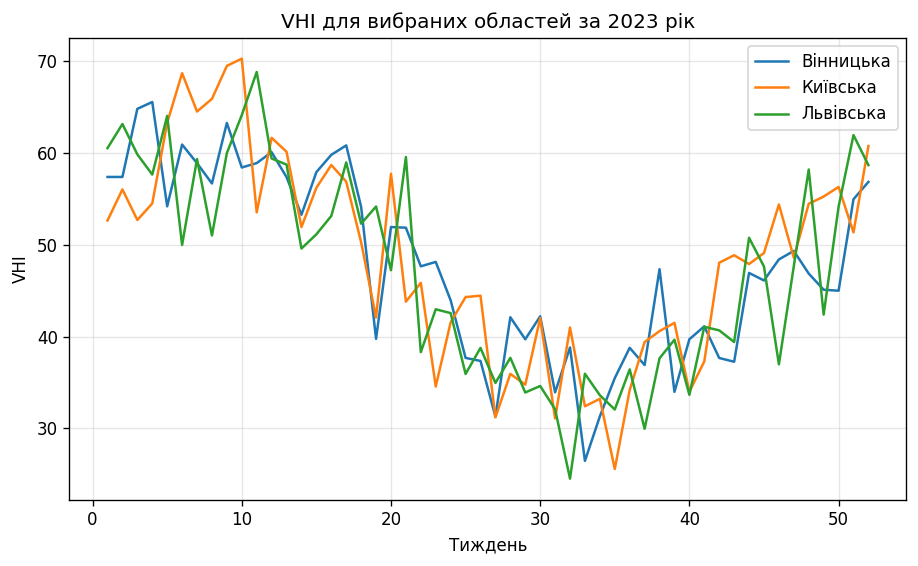

In [11]:
plt.figure(figsize=(9, 5))

for region in ["Вінницька", "Київська", "Львівська"]:
    d = vhi_df[(vhi_df["Province"] == region) & (vhi_df["Year"] == 2023)]
    plt.plot(d["Week"], d["VHI"], label=region)

plt.title("VHI для вибраних областей за 2023 рік")
plt.xlabel("Тиждень")
plt.ylabel("VHI")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Висновок

У першій частині лабораторної роботи було підготовлено набір даних VHI/VCI/TCI, виконано перевірку структури даних, реалізовано окремі функції для формування вибірок та побудовано графік для аналізу значень VHI по областях.